In [4]:
import pandas as pd

from mlxtend.frequent_patterns import apriori
from mlxtend.frequent_patterns import association_rules

import warnings
warnings.filterwarnings("ignore")

import re
df = pd.read_csv("OnlineRetail.csv", encoding="latin1")


In [3]:
#dimensions of the data
df.shape

(541909, 8)

In [3]:
# sanity checks
print(df.isnull().sum())
print(df.describe)

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64
<bound method NDFrame.describe of        InvoiceNo StockCode                          Description  Quantity  \
0         536365    85123A   WHITE HANGING HEART T-LIGHT HOLDER         6   
1         536365     71053                  WHITE METAL LANTERN         6   
2         536365    84406B       CREAM CUPID HEARTS COAT HANGER         8   
3         536365    84029G  KNITTED UNION FLAG HOT WATER BOTTLE         6   
4         536365    84029E       RED WOOLLY HOTTIE WHITE HEART.         6   
...          ...       ...                                  ...       ...   
541904    581587     22613          PACK OF 20 SPACEBOY NAPKINS        12   
541905    581587     22899         CHILDREN'S APRON DOLLY GIRL          6   
541906    581587     23254        CHILDRENS CUTLERY DOLLY GIRL          4   
541907 

In [9]:
# cleaning
# #drop null descriptions
df.dropna(axis=0, subset=["Description"], inplace=True) #axis0 focus on rows, subset(area), inplace applys drop to dataset

##remove trailing/leading spaces - not to confuse grouping, (s+- represent one or more spaces)
df['Description'] = df['Description'].astype('str').apply(lambda x: re.sub(r'\s+', ' ', x).strip())

#remove canceled out (~)-means to exclude
df = df[~df['InvoiceNo'].str.contains('C')]

df.shape

(531167, 8)

In [8]:
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description         0
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     133243
Country             0
dtype: int64

In [11]:
#sample cancelled transactions
#df[df['InvoiceNo'].str.contains('C')].sample(10)

#remove canceled out (~)-means to exclude
df = df[~df['InvoiceNo'].str.contains('C')]
df.shape

(531167, 8)

In [12]:
#countrys
#df['Country'].unique() #number of countries
#
df['Country'].value_counts().head(10) #normalize=True --outputs count
df['Country'].value_counts(normalize=True).head(5) ##normalize=True --outputs proportion

#i wanted to see how many transactions each country had - groupby country, select unique invoice number
#df.groupby('Country')['InvoiceNo'].nunique()

Country
United Kingdom    0.915283
Germany           0.017023
France            0.015829
EIRE              0.014862
Spain             0.004678
Name: proportion, dtype: float64

In [13]:
# END OF CLEANING, MADE DECISION OF WHICH DATA IS VALID

In [14]:
#BUILT TRANSACTION MATRIX

In [10]:
#i want to focus on uk, TRANSACTION MATRIX

uk_df = (df[df['Country'] == 'United Kingdom']
          .groupby(['InvoiceNo', 'Description']) #column focused on
         .size() # counts of transactions
          .unstack() #converts descriptions in columns
          .fillna(0) #
          .reset_index() #due to removed rows, reset index and use and order data by invoiceno as index
          .set_index('InvoiceNo'))

print(uk_df.shape)
#uk_df.head(5)

(18668, 4168)


In [12]:
#dropping postage(SHIPPING COST/FEES)

uk_df = uk_df.drop(columns=['POSTAGE'], errors='ignore')

remove_words = ['POSTAGE', 'DOTCOM', 'CARRIAGE', 'MANUAL']

uk_df = uk_df.loc[:,
    ~uk_df.columns.str.contains('|'.join(remove_words), case=False)
]

uk_df = uk_df.astype(int) # converted true/false to integer(1&0s)

uk_df.head()

#screenshot of the uk_df.head() output showing the 0/1 binary matrix)

Description,*Boombox Ipod Classic,*USB Office Mirror Ball,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,...,wrongly coded 20713,wrongly coded 23343,wrongly coded-23343,wrongly marked,wrongly marked 23343,wrongly marked carton 22804,wrongly marked. 23343 in box,wrongly sold (22719) barcode,wrongly sold as sets,wrongly sold sets
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
# COUNT VS PRESENCE - SOME VALUES WERE <1, >1, ALL CARE FOR WAS THE PRODUCT PRESENT, NOT HOW MANY UNITS WERE PURCHASED

In [18]:
#sanity checks
# #uk_df.iloc[:5, :5] #show first 5

#uk_df.sum().sort_values(ascending=False).head(10) # uk_df.sum().sort_values(ascending=False).head(10)

#uk_df.max().max()


In [19]:
#convert positive values to 1, any less becomes 0 - quantity
#def custom_encoding(x):
#   if x<=0:
 #       return 0
#   if x>=1:
 #       return 1

#apply function to dataset
#uk_df = uk_df.applymap(custom_encoding)

#i wanted to use a function and apply to the dataset

In [18]:
uk_df = uk_df>0 #COMPARES WHOLE MATRIX AT ONCE, I BELEIVE THIS CHANGES IT TO A BOOLEAN

uk_df = uk_df.astype(int) # converted true/false to integer(1&0s)
#VECTOR THINKING

uk_df.head(5)

Description,*Boombox Ipod Classic,*USB Office Mirror Ball,10 COLOUR SPACEBOY PEN,12 COLOURED PARTY BALLOONS,12 DAISY PEGS IN WOOD BOX,12 EGG HOUSE PAINTED WOOD,12 HANGING EGGS HAND PAINTED,12 IVORY ROSE PEG PLACE SETTINGS,12 MESSAGE CARDS WITH ENVELOPES,12 PENCIL SMALL TUBE WOODLAND,...,wrongly coded 20713,wrongly coded 23343,wrongly coded-23343,wrongly marked,wrongly marked 23343,wrongly marked carton 22804,wrongly marked. 23343 in box,wrongly sold (22719) barcode,wrongly sold as sets,wrongly sold sets
InvoiceNo,,,,,,,,,,,,,,,,,,,,,
536365,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536366,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536367,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536368,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
536369,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
uk_df.shape

(18668, 4134)

In [19]:
#APRIOR, frquent items

frequent_itemsets = apriori(
    uk_df,
    min_support=0.02,
    use_colnames=True
) #1% too large, so used 2%
frequent_itemsets.shape

(368, 2)

In [20]:
#generating rules

rules = association_rules(
    frequent_itemsets,
    metric='confidence',
    min_threshold=0.3
)

rules.shape
#rules.sort_values(by='lift', ascending=False)

(155, 14)

In [24]:
uk_df.shape


(18668, 4134)

In [21]:
# we generated 75(158) rules, now we need to filter and focus on strong rules

strong_rule = rules[
    (rules['confidence'] >= 0.5) &
    (rules['lift'] >= 2)
]

strong_rule.shape


(63, 14)

In [26]:
#to see strongest patterns clearly, remove trivial variations

strong_rule = strong_rule.sort_values(by='lift', ascending=False)

strong_rule[['antecedents','consequents','support','confidence','lift']].head(10)

,antecedents,consequents,support,confidence,lift
143,(PINK REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",0.026409,0.701280,18.675463
140,"(GREEN REGENCY TEACUP AND SAUCER, ROSES REGENC...",(PINK REGENCY TEACUP AND SAUCER),0.026409,0.703281,18.675463
141,"(ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY...",(GREEN REGENCY TEACUP AND SAUCER),0.026409,0.902930,18.047007
142,(GREEN REGENCY TEACUP AND SAUCER),"(ROSES REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.026409,0.527837,18.047007
139,"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",(ROSES REGENCY TEACUP AND SAUCER),0.026409,0.854419,16.666982
144,(ROSES REGENCY TEACUP AND SAUCER),"(GREEN REGENCY TEACUP AND SAUCER, PINK REGENCY...",0.026409,0.515152,16.666982
23,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.030909,0.820768,16.404818
22,(GREEN REGENCY TEACUP AND SAUCER),(PINK REGENCY TEACUP AND SAUCER),0.030909,0.617773,16.404818
18,(SPACEBOY LUNCH BOX),(DOLLY GIRL LUNCH BOX),0.022820,0.607703,16.229764
19,(DOLLY GIRL LUNCH BOX),(SPACEBOY LUNCH BOX),0.022820,0.609442,16.229764


collection behavior(same product family) appears to be dominant,

In [27]:
#need to filter dominate category to find insights for cross category
#1st filter
filter_strong_rules = strong_rule[
    ~(
            strong_rule['antecedents'].astype(str).str.contains('REGENCY') &
            strong_rule['consequents'].astype(str).str.contains('REGENCY')
    )
]

filter_strong_rules.sort_values(by='lift', ascending=False)[
    ['antecedents','consequents','support','confidence','lift']
].head(10)

,antecedents,consequents,support,confidence,lift
18,(SPACEBOY LUNCH BOX),(DOLLY GIRL LUNCH BOX),0.022820,0.607703,16.229764
19,(DOLLY GIRL LUNCH BOX),(SPACEBOY LUNCH BOX),0.022820,0.609442,16.229764
134,(WOODLAND CHARLOTTE BAG),(STRAWBERRY CHARLOTTE BAG),0.020034,0.547584,15.189155
135,(STRAWBERRY CHARLOTTE BAG),(WOODLAND CHARLOTTE BAG),0.020034,0.555721,15.189155
21,(GARDENERS KNEELING PAD CUP OF TEA),(GARDENERS KNEELING PAD KEEP CALM),0.028980,0.721333,14.995379
20,(GARDENERS KNEELING PAD KEEP CALM),(GARDENERS KNEELING PAD CUP OF TEA),0.028980,0.602450,14.995379
9,(RED RETROSPOT CHARLOTTE BAG),(CHARLOTTE BAG PINK POLKADOT),0.025659,0.529282,14.659691
8,(CHARLOTTE BAG PINK POLKADOT),(RED RETROSPOT CHARLOTTE BAG),0.025659,0.710682,14.659691
15,(WOODLAND CHARLOTTE BAG),(CHARLOTTE BAG SUKI DESIGN),0.022123,0.604685,14.040129
14,(CHARLOTTE BAG SUKI DESIGN),(WOODLAND CHARLOTTE BAG),0.022123,0.513682,14.040129


similar to previous line:
stronger_rules = filter_strong_rules[
    (filter_strong_rules['antecedents'].apply(lambda x: len(x)) == 1)&
    (filter_strong_rules['consequents'].apply(lambda x: len(x)) == 1)
     ]

stronger_rules.sort_values(by='lift', ascending=False)[
    ['antecedents','consequents','support','confidence','lift']].head(10)

In [53]:
#i want to find cross category
cross_category_rule = rules[
    (rules['lift'] >= 1.5) &
    (rules['support'] >= 0.03) &
    (rules['confidence'] >= 0.5)]

cross_category_rule.shape

cross_category_rule = cross_category_rule.sort_values(by='lift', ascending=True)

cross_category_rule[['antecedents','consequents','support','confidence','lift']].head(20)

,antecedents,consequents,support,confidence,lift
57,(JUMBO SHOPPER VINTAGE RED PAISLEY),(JUMBO BAG RED RETROSPOT),0.035194,0.579876,5.585724
60,(JUMBO STORAGE BAG SUKI),(JUMBO BAG RED RETROSPOT),0.037390,0.617699,5.950055
36,(JUMBO BAG BAROQUE BLACK WHITE),(JUMBO BAG RED RETROSPOT),0.030534,0.626374,6.033613
41,(JUMBO BAG PINK POLKADOT),(JUMBO BAG RED RETROSPOT),0.042051,0.677308,6.524245
109,(LUNCH BAG SUKI DESIGN),(LUNCH BAG RED RETROSPOT),0.032248,0.501249,6.722209
2,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE GREEN),0.030159,0.605376,12.900874
3,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.030159,0.642694,12.900874
26,(ROSES REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.037551,0.732497,14.640537
25,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.037551,0.750535,14.640537
23,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.030909,0.820768,16.404818


In [45]:
#cross sell oportunity

cross_sell = rules[
    (rules['support'] >= 0.03) &
    (rules['confidence'] >= 0.5)]

cross_sell = cross_sell.sort_values(by='lift', ascending=True)

cross_sell[['antecedents','consequents','support','confidence','lift']].head(10)

,antecedents,consequents,support,confidence,lift
57,(JUMBO SHOPPER VINTAGE RED PAISLEY),(JUMBO BAG RED RETROSPOT),0.035194,0.579876,5.585724
60,(JUMBO STORAGE BAG SUKI),(JUMBO BAG RED RETROSPOT),0.037390,0.617699,5.950055
36,(JUMBO BAG BAROQUE BLACK WHITE),(JUMBO BAG RED RETROSPOT),0.030534,0.626374,6.033613
41,(JUMBO BAG PINK POLKADOT),(JUMBO BAG RED RETROSPOT),0.042051,0.677308,6.524245
109,(LUNCH BAG SUKI DESIGN),(LUNCH BAG RED RETROSPOT),0.032248,0.501249,6.722209
2,(ALARM CLOCK BAKELIKE RED),(ALARM CLOCK BAKELIKE GREEN),0.030159,0.605376,12.900874
3,(ALARM CLOCK BAKELIKE GREEN),(ALARM CLOCK BAKELIKE RED),0.030159,0.642694,12.900874
26,(ROSES REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.037551,0.732497,14.640537
25,(GREEN REGENCY TEACUP AND SAUCER),(ROSES REGENCY TEACUP AND SAUCER),0.037551,0.750535,14.640537
23,(PINK REGENCY TEACUP AND SAUCER),(GREEN REGENCY TEACUP AND SAUCER),0.030909,0.820768,16.404818


insight - cross category

WHITE HANGING HEART T-LIGHT HOLDER is a central product for customers seeking to buy decorative items

we notice customers in bag ecosystem, customers often complement there different bag purchase with JUMBO BAG RED RETROSPOT

party theme - SPOTTY BUNTING → PARTY BUNTING (Lift 5.08): customers preparing for an event buy multiple decor items

Table setting expansion behavior.
ROSES REGENCY TEACUP → REGENCY CAKESTAND 3 TIER (Lift 5.25)
Customers are building a coordinated tea setup.
That’s a real bundle opportunity.

In [14]:
import matplotlib.pyplot as plt
#import plotly.express as px

In [15]:
#VISUALIZATION
#SUPPORT VS CONFIDENCE
plt.figure()
plt.scatter(rules['support'], rules['confidence'], s=rules['lift']*15 )

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Relationship between support and confidence")
plt.show()

NameError: name 'rules' is not defined

<Figure size 640x480 with 0 Axes>

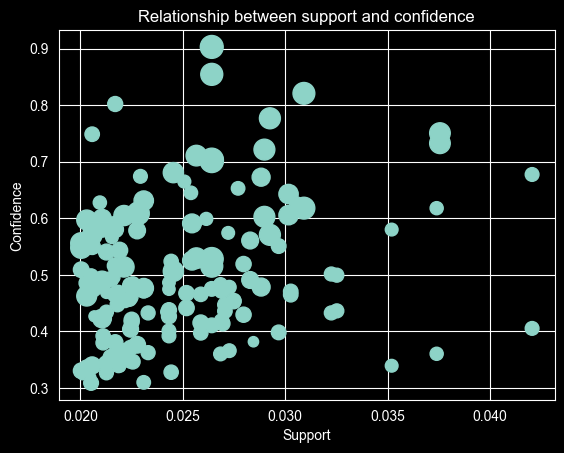

In [31]:
#VISUALIZATION
#SUPPORT VS CONFIDENCE
plt.figure()
plt.scatter(cross_category_rule['support'], cross_category_rule['confidence'], s=cross_category_rule['lift']*15 )

plt.xlabel("Support")
plt.ylabel("Confidence")
plt.title("Relationship between support and confidence")
plt.show()

In [54]:
# run once in your analysis workflow
rules.to_csv("rules.csv", index=False)